In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import xarray as xr

import cmocean
from glob import glob
import cartopy
from cartopy.crs import PlateCarree, Geodetic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter('ignore')

# Set Parameters

In [2]:
year = 2020

In [3]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
sample_points_file_path = project_folder_path / 'output/sample_points/sample_points.geojson'
trajectory_path = project_folder_path / f'output/Trajectories/{year}/'
connectivity_matrix_folder_path = project_folder_path / 'output/VoronoiConnectivity/'
figure_output_path = project_folder_path / 'Figures/connectivity_matrices/'
voronoi_polygons_moved_file_path = project_folder_path / "output/sample_points/voronoi_polygons_moved.geojson"
voronoi_polygons_original_file_path = project_folder_path / "output/sample_points/voronoi_polygons_original.geojson"
voronoi_polygons_moved = gpd.read_file(voronoi_polygons_moved_file_path)
voronoi_polygons_original = gpd.read_file(voronoi_polygons_original_file_path)

In [4]:
sample_points = gpd.read_file(sample_points_file_path)

In [5]:
def check_valid(dataset, min_distance=0.1):
        valid_trajectory = traj_is_valid(dataset, min_distance).broadcast_like(dataset)
        return dataset.where(valid_trajectory, drop=True).compute()

In [6]:
def traj_is_valid(dataset, min_distance=0.1):
        dataset_daily = dataset.chunk({'obs': 1, 'trajectory': -1}).isel(obs=np.arange(0, 28*4*24, 4*24*2)).compute()
        distance_xy_abs = np.abs(dataset_daily - dataset_daily.isel(obs=0)).max(dim='obs', skipna=True)
        return ((distance_xy_abs.lat**2 + distance_xy_abs.lon**2)**(1/2) > min_distance)

In [7]:
trajectory_file = sorted(trajectory_path.glob(f'*WH02*'))[0]
trajectories = xr.open_zarr(trajectory_file).get(['lat', 'lon', 'time']).drop_isel(obs=np.arange(-(23*4+3), 0))
mask_november = (trajectories.time.isel(obs=0).chunk({'trajectory': -1}).compute() < np.datetime64(f'{year}-11')).broadcast_like(trajectories)
# trajectories = trajectories.where(mask_november, drop=True)

In [ ]:
for year in range(2016, 2025):
        trajectory_path = project_folder_path / f'output/Trajectories/{year}/'
        sample_points[f'valid_particles_{year}'] = np.empty(len(sample_points))
        for index, loc_id in enumerate(sample_points.location_id_old):
                trajectory_file = list(trajectory_path.glob(f'*{loc_id}*'))[0]
                print(year, index, loc_id, trajectory_file)
                trajectories = xr.open_zarr(trajectory_file).get(['lat', 'lon']).drop_isel(obs=np.arange(-(23*4+3), 0)).where(mask_november, drop=True)
                n_valid_trajectories = traj_is_valid(trajectories).sum().values
                sample_points.loc[[index], [f'valid_particles_{year}']] = n_valid_trajectories

2016 0 WH02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_WH02_d0m-25m_N1000_seed123.zarr
2016 1 SK01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_SK01_d0m-25m_N1000_seed123.zarr
2016 2 DB02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_DB02_d0m-25m_N1000_seed123.zarr
2016 3 DB01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_DB01_d0m-25m_N1000_seed123.zarr
2016 4 JB01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_JB01_d0m-25m_N1000_seed123.zarr
2016 5 SR02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601-20161130_dt15min_SR02_d0m-25m_N1000_seed123.zarr
2016 6 SR03 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2016/PPmill_Nested_20160601

In [ ]:
sample_points

In [5]:
# Set the basic mapping parameters
suptitle_size = 20
axis_size = 16
mapsize = (16, 16)
extent = (7, 10, 53, 55)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()

In [6]:
def basemap(ax, extent=extent):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [7]:
start_month = 6
start_day = 1
end_month = 9
end_day = 30
start_date = np.datetime64(f'{year}-{start_month:02d}-{start_day:02d}', 'D')
end_date = np.datetime64(f'{year}-{end_month:02d}-{end_day:02d}', 'D')
first_day_in_year = np.datetime64(f'{year}-01-01', 'D')

start_date_str = start_date.astype(str).replace('-','')
end_date_str = end_date.astype(str).replace('-','')

start_file = (start_date - first_day_in_year).astype(int) * 4-1
end_file = (end_date - first_day_in_year + 1).astype(int) * 4+1

In [8]:
folder_path_bsh_400 = Path('/gxfs_work/geomar/smomw400/bsh_operationalmodel_data/')
c_files_fine = sorted(folder_path_bsh_400.glob(f'c_file_fine_{year}/*'))[start_file:end_file]
current = xr.open_mfdataset(c_files_fine[0:5]).isel(layer_number=0).drop('wvel')
lon_condition = (current.lon < extent[1]) & (extent[0] < current.lon)
lat_condition = (current.lat < extent[3]) & (extent[2] < current.lat)
current = current.where(lon_condition & lat_condition, drop=True).chunk({'time': 1000, 'lat': 1000, 'lon': 1000}).compute().mean('time')
abs_current = (current.uvel**2 + current.vvel**2)**(1/2)

In [239]:
# Read and prepare the trajectory file
trajectory_file = sorted(trajectory_path.glob(f'*WH01*'))[0]
trajectory_WH01 = xr.open_zarr(trajectory_file).get(['lat','lon']).drop_isel(obs=np.arange(-(23*4+3), 0))
# trajectory_file = sorted(trajectory_path.glob(f'*WH02*'))[0]
# trajectory_WH02 = xr.open_zarr(trajectory_file).get(['lat','lon']).drop_isel(obs=np.arange(-(23*4+3), 0))
# trajectory_file = sorted(trajectory_path.glob(f'*SK01*'))[0]
# trajectory_SK01 = xr.open_zarr(trajectory_file).get(['lat','lon']).drop_isel(obs=np.arange(-(23*4+3), 0))
# trajectory_file = sorted(trajectory_path.glob(f'*SK02*'))[0]
# trajectory_SK02 = xr.open_zarr(trajectory_file).get(['lat','lon']).drop_isel(obs=np.arange(-(23*4+3), 0))
trajectory_WH01.isel(obs=-1).max(skipna=True).compute()
dataset_null = trajectory_WH01.isel(obs=4*24).compute().lat.isnull()
trajectory_WH01.where(dataset_null.broadcast_like(trajectory_WH01), drop=True)

<xarray.Dataset> Size: 43MB
Dimensions:     (trajectory: 1000, obs: 2689)
Coordinates:
  * obs         (obs) int32 11kB 0 1 2 3 4 5 6 ... 2683 2684 2685 2686 2687 2688
  * trajectory  (trajectory) int64 8kB 181000 181001 181002 ... 181998 181999
Data variables:
    lat         (trajectory, obs) float64 22MB dask.array<chunksize=(1000, 96), meta=np.ndarray>
    lon         (trajectory, obs) float64 22MB dask.array<chunksize=(1000, 96), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_3D_SIGMABSHAgingDeleteErr...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [ ]:
for file in sorted(trajectory_path.glob(f'*')):
        print(file.name)
        trajectories = xr.open_zarr(file).get(['lat', 'lon', 'time']).drop_isel(obs=np.arange(-(23*4+3), 0))
        trajectories = trajectories.where(mask_november, drop=True)

In [158]:
sample_points

,location_name,location_id,location_id_old,sample_kind,genomic_data,sea,sea_surface_area,geometry
0,Wilhelmshaven_moved,WH02,WH02,moved,True,northsea,7000.168785,POINT (8.15 53.637)
1,Speicherkoog,SK01,SK01,real,True,northsea,3690.914311,POINT (8.9487 54.0929)
2,DeutscheBucht02,DB02,DB02,digital,False,northsea,20880.929074,POINT (7.5 54.6)
3,DeutscheBucht01,DB01,DB01,digital,False,northsea,21130.793843,POINT (7.25 55.5)
4,JutlandBay,JB01,JB01,digital,False,northsea,22286.896977,POINT (7.3 56.5)
5,Skagerak02,SR02,SR02,digital,False,northsea,21377.355840,POINT (8 57.5)
6,Skagerak03,SR03,SR03,digital,False,northsea,11478.888155,POINT (9.3 58.3)
7,Skagerak01,SR01,SR01,digital,False,northsea,14048.382555,POINT (10.5 58)
8,Kategat02,KG02,KG02,digital,False,northsea,11305.779121,POINT (11.5 57)
9,Kategat01,KG01,KG01,digital,False,northsea,13590.026876,POINT (11.8 56.35)


In [152]:
sample_points[f'valid_particles_{year}'] = np.empty(len(sample_points))
for index, loc_id in enumerate(sample_points.location_id_old):
        trajectory_file = list(trajectory_path.glob(f'*{loc_id}*'))[0]
        trajectories = xr.open_zarr(trajectory_file).get(['lat', 'lon']).drop_isel(obs=np.arange(-(23*4+3), 0)).where(mask_november, drop=True)
        print(index, loc_id, trajectory_file)
        n_valid_trajectories = traj_is_valid(trajectories).sum().values
        sample_points.loc[[index], [f'valid_particles_{year}']] = n_valid_trajectories

0 WH02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_WH02_d0m-25m_N1000_seed123.zarr
1 SK01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_SK01_d0m-25m_N1000_seed123.zarr
2 DB02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_DB02_d0m-25m_N1000_seed123.zarr
3 DB01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_DB01_d0m-25m_N1000_seed123.zarr
4 JB01 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_JB01_d0m-25m_N1000_seed123.zarr
5 SR02 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_SR02_d0m-25m_N1000_seed123.zarr
6 SR03 /gxfs_work/geomar/smomw597/2025_copepods/output/Trajectories/2020/PPmill_Nested_20200601-20201130_dt15min_SR03_d0m-25m_N100

In [74]:
len(a.trajectory)

153000

In [71]:
check_valid(trajectory_WH01)

<xarray.Dataset> Size: 807MB
Dimensions:     (trajectory: 18111, obs: 2784)
Coordinates:
  * obs         (obs) int32 11kB 0 1 2 3 4 5 6 ... 2778 2779 2780 2781 2782 2783
  * trajectory  (trajectory) int64 145kB 1 7 9 12 13 ... 77989 77992 77994 77998
Data variables:
    lat         (trajectory, obs) float64 403MB 53.5 53.5 53.5 ... nan nan nan
    lon         (trajectory, obs) float64 403MB 8.133 8.133 8.133 ... nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_3D_SIGMABSHAgingDeleteErr...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [9]:
test = trajectory_WH01.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_WH01_far = trajectory_WH01.where(far_dist.broadcast_like(trajectory_WH01), drop=True)

In [10]:
test = trajectory_WH02.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_WH02_far = trajectory_WH02.where(far_dist.broadcast_like(trajectory_WH02), drop=True)

In [11]:
test = trajectory_SK01.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_SK01_far = trajectory_SK01.where(far_dist.broadcast_like(trajectory_SK01), drop=True)

In [12]:
test = trajectory_SK02.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_SK02_far = trajectory_SK02.where(far_dist.broadcast_like(trajectory_SK02), drop=True)

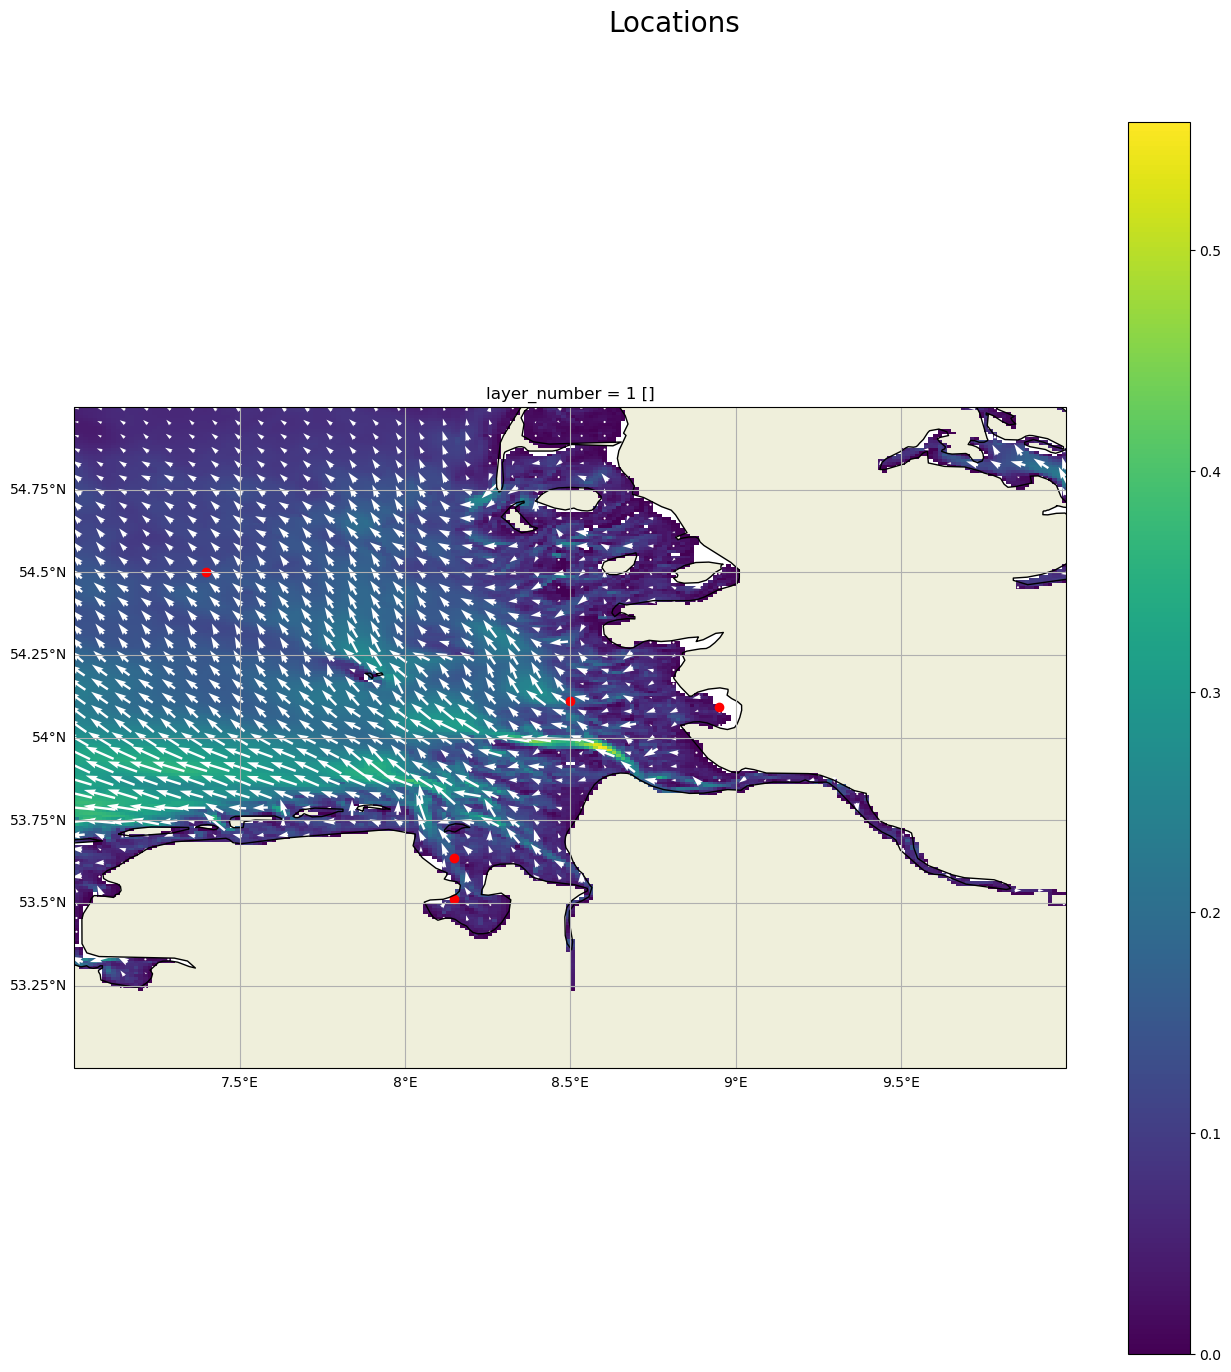

In [24]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, extent)
abs_current.plot(ax=ax_map)
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
ax_map.scatter(x=sample_points.geometry.x, y=sample_points.geometry.y, color='red')
plt.show()

In [94]:
df_WH01 = trajectory_WH01_far.to_dataframe().reset_index() #.to_crs(Geodetic())
gdf_WH01 = gpd.GeoDataFrame(df_WH01.trajectory, geometry=gpd.points_from_xy(df_WH01.lon, df_WH01.lat, crs=Geodetic()))
gdf_WH01

,trajectory,geometry
0,1878,POINT (8.15112 53.51432)
1,1878,POINT (8.15112 53.51561)
2,1878,POINT (8.15112 53.51561)
3,1878,POINT (8.15112 53.51596)
4,1878,POINT (8.15112 53.51633)
...,...,...
27835,56221,POINT EMPTY
27836,56221,POINT EMPTY
27837,56221,POINT EMPTY
27838,56221,POINT EMPTY


<Axes: >

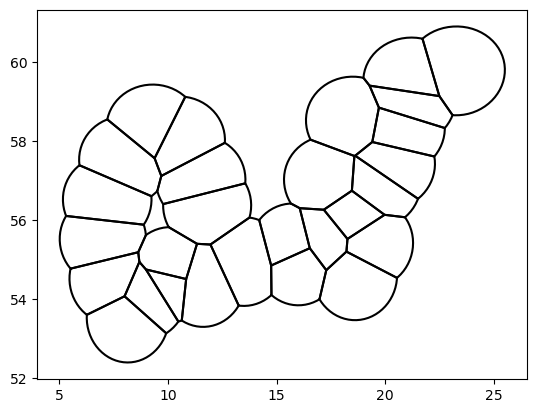

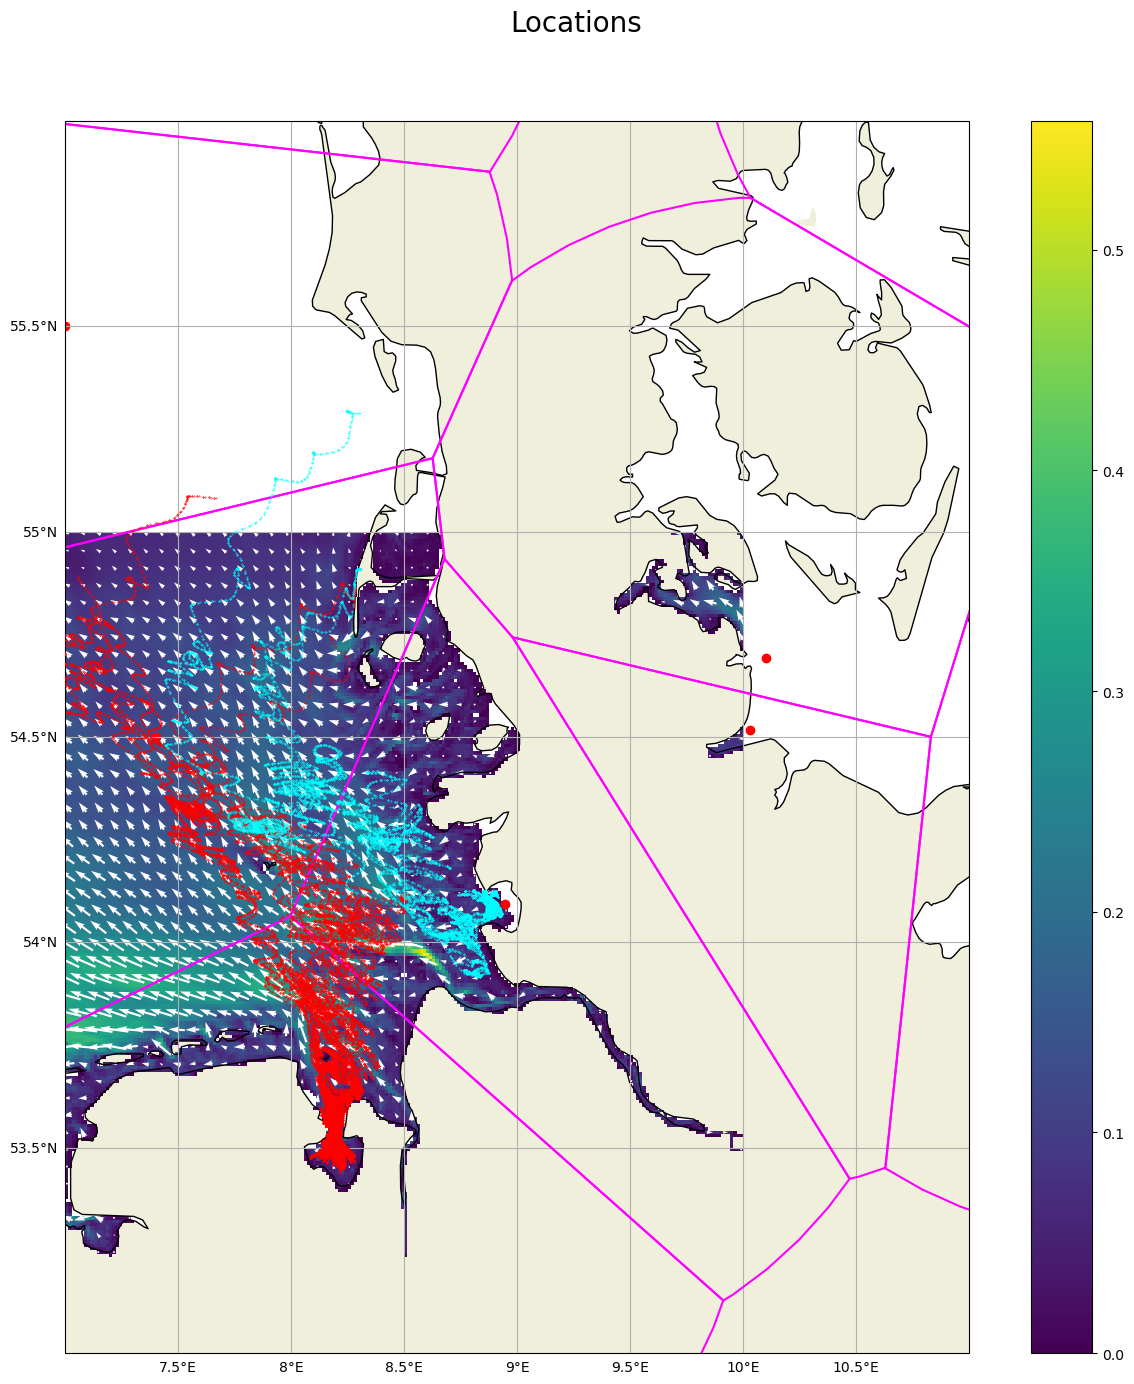

In [25]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, (7, 11, 53, 56))
abs_current.plot(ax=ax_map)
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
trajectory_WH01_far.plot.scatter(x='lon', y='lat', color='red', s=0.1, ax=ax_map, zorder=10)
trajectory_SK01_far.plot.scatter(x='lon', y='lat', color='cyan', s=0.1, ax=ax_map, zorder=10)
voronoi_polygons_original.geometry.boundary.plot(color='magenta', ax=ax_map)
ax_map.scatter(x=sample_points.geometry.x, y=sample_points.geometry.y, color='red')
plt.show()

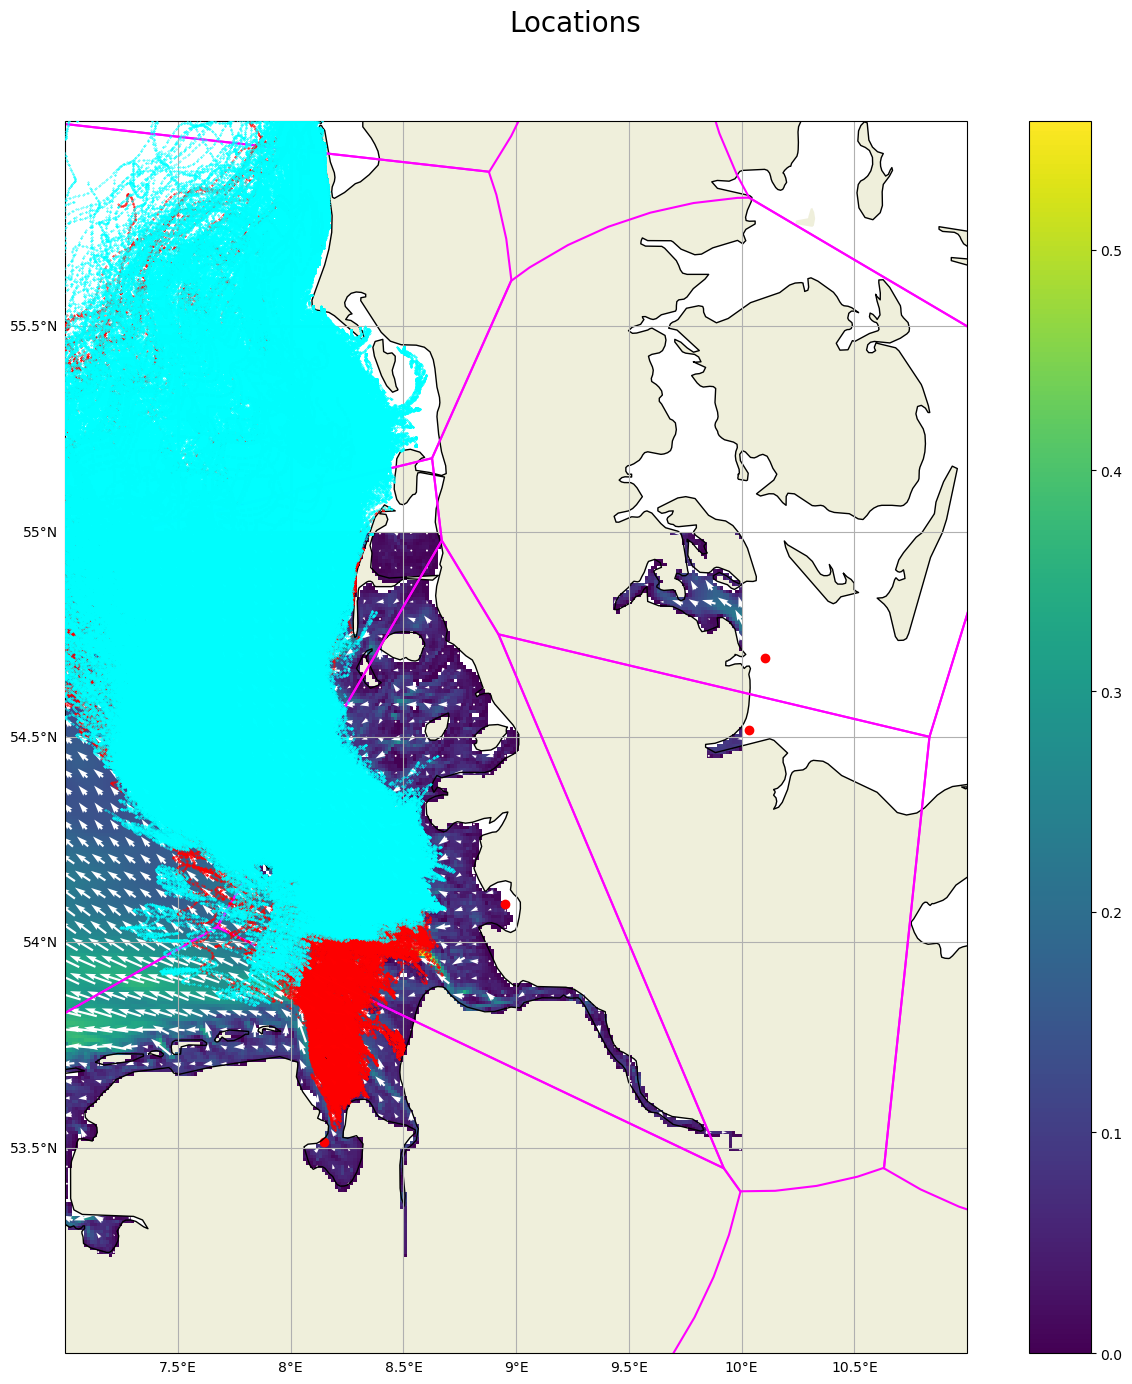

In [26]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, (7, 11, 53, 56))
abs_current.plot(ax=ax_map)
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
trajectory_WH02_far.plot.scatter(x='lon', y='lat', color='red', s=0.1, ax=ax_map, zorder=10)
trajectory_SK02_far.plot.scatter(x='lon', y='lat', color='cyan', s=0.1, ax=ax_map, zorder=10)
voronoi_polygons_moved.geometry.boundary.plot(color='magenta', ax=ax_map)
ax_map.scatter(x=sample_points.geometry.x, y=sample_points.geometry.y, color='red')
plt.show()